Extracting features...
Feature matrix shape: (10027, 53)


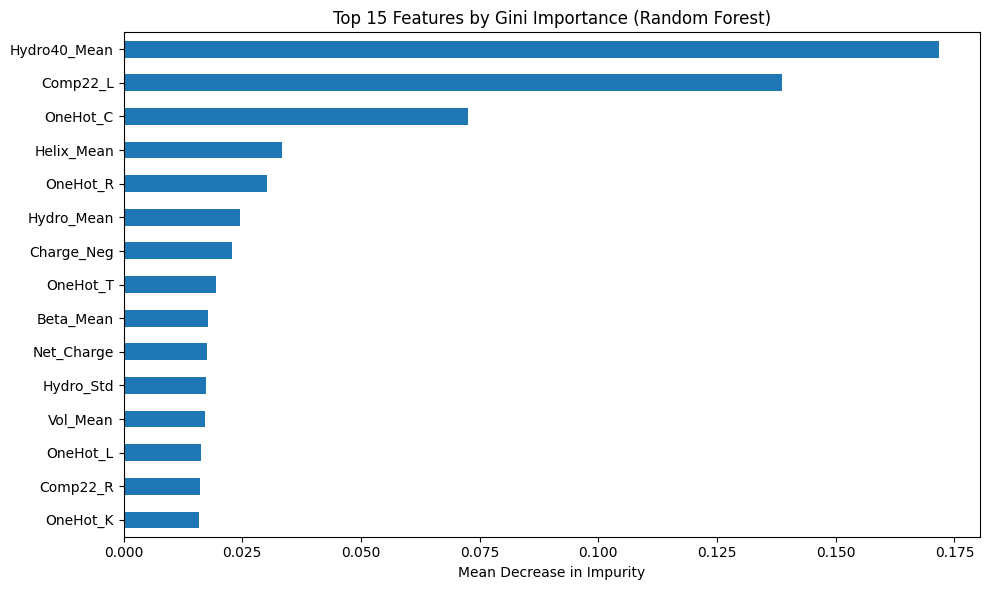

Running GridSearchCV with embedded feature selection...

BEST MODEL RESULTS (SVM + RF Feature Selection)
Best CV AUC: 0.9716
Best parameters: {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}

Selected 30 features:
 - Hydro40_Mean
 - Comp22_L
 - OneHot_C
 - Helix_Mean
 - OneHot_R
 - Hydro_Mean
 - Charge_Neg
 - OneHot_T
 - Beta_Mean
 - Hydro_Std
 - Vol_Mean
 - Comp22_R
 - Net_Charge
 - OneHot_K
 - OneHot_L
 - OneHot_Y
 - OneHot_M
 - OneHot_I
 - OneHot_E
 - OneHot_W
 - Comp22_E
 - OneHot_N
 - OneHot_S
 - Comp22_A
 - OneHot_P
 - Vol_Std
 - OneHot_D
 - OneHot_F
 - OneHot_G
 - OneHot_V


In [ ]:
# Custom Feature Extraction & Selection Pipeline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("../Data_Preparation/data.tsv", sep="\t")

# Encode labels: Positive → 1, Negative → 0
le = LabelEncoder()
y = le.fit_transform(df['Label'])
sequences = df['Sequence'].astype(str).tolist()

# CUSTOM FEATURE EXTRACTION (DOMAIN-AWARE)

AA_ORDER = "ACDEFGHIKLMNPQRSTVWY"

HYDROPATHY = {'A': 1.8, 'R': -4.5, 'N': -3.5, 'D': -3.5, 'C': 2.5,
              'Q': -3.5, 'E': -3.5, 'G': -0.4, 'H': -3.5, 'I': 4.5,
              'L': 3.8, 'K': -3.9, 'M': 1.9, 'F': 2.8, 'P': -1.6,
              'S': -0.8, 'T': -0.7, 'W': -0.9, 'Y': -1.3, 'V': 4.2}

VOLUME = {'A': 31.0, 'R': 124.0, 'N': 56.0, 'D': 54.0, 'C': 55.0,
          'Q': 85.0, 'E': 83.0, 'G': 3.0, 'H': 96.0, 'I': 111.0,
          'L': 111.0, 'K': 119.0, 'M': 94.0, 'F': 132.0, 'P': 32.0,
          'S': 32.0, 'T': 61.0, 'W': 170.0, 'Y': 136.0, 'V': 84.0}

HELIX_PROPENSITY = {'A': 1.45, 'R': 0.98, 'N': 0.76, 'D': 0.54, 'C': 0.77,
                    'Q': 1.10, 'E': 1.53, 'G': 0.53, 'H': 1.24, 'I': 1.00,
                    'L': 1.34, 'K': 1.07, 'M': 1.20, 'F': 1.12, 'P': 0.59,
                    'S': 0.79, 'T': 0.82, 'W': 1.14, 'Y': 0.61, 'V': 0.97}

BETA_PROPENSITY = {'A': 0.83, 'R': 0.93, 'N': 0.89, 'D': 0.54, 'C': 1.19,
                   'Q': 1.10, 'E': 0.37, 'G': 0.75, 'H': 0.87, 'I': 1.60,
                   'L': 1.30, 'K': 0.74, 'M': 1.05, 'F': 1.38, 'P': 0.55,
                   'S': 0.75, 'T': 1.19, 'W': 1.37, 'Y': 1.47, 'V': 1.70}

def extract_features(seq):
    seq = ''.join([aa for aa in seq.upper() if aa in AA_ORDER]) or "A"
    features = []

    # 1. One-hot mean pooling (20)
    one_hot = np.zeros((len(seq), 20))
    for i, aa in enumerate(seq):
        one_hot[i, AA_ORDER.index(aa)] = 1.0
    features.extend(np.mean(one_hot, axis=0))

    # 2. AA composition (first 22 residues)
    sub22 = seq[:22]
    comp = [sub22.count(aa) / len(sub22) for aa in AA_ORDER]
    features.extend(comp)

    # 3. Hydrophobicity (first 40 residues)
    sub40 = seq[:40]
    hydro = [HYDROPATHY.get(aa, 0) for aa in sub40]
    features.append(np.mean(hydro))
    features.append(np.max(hydro))

    # 4. Charge (first 10 residues)
    sub10 = seq[:10]
    pos = sub10.count('K') + sub10.count('R')
    neg = sub10.count('D') + sub10.count('E')
    features.extend([pos, neg, pos - neg])

    # 5. Global physicochemical stats (mean + std for 4 properties)
    for prop in [HYDROPATHY, VOLUME, HELIX_PROPENSITY, BETA_PROPENSITY]:
        vals = [prop.get(aa, 0) for aa in seq]
        features.append(np.mean(vals))
        features.append(np.std(vals))

    return np.array(features)

# Build feature names for interpretability
feature_names = (
    [f"OneHot_{aa}" for aa in AA_ORDER] +
    [f"Comp22_{aa}" for aa in AA_ORDER] +
    ["Hydro40_Mean", "Hydro40_Max"] +
    ["Charge_Pos", "Charge_Neg", "Net_Charge"] +
    ["Hydro_Mean", "Hydro_Std", "Vol_Mean", "Vol_Std",
     "Helix_Mean", "Helix_Std", "Beta_Mean", "Beta_Std"]
)

print("Extracting features...")
X = np.array([extract_features(seq) for seq in sequences])
print(f"Feature matrix shape: {X.shape}")


# RANDOM FOREST + FEATURE IMPORTANCE
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)

importance_series = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance_series.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Features by Gini Importance (Random Forest)")
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

# CUSTOM TRANSFORMER: SELECT TOP-K FEATURES BY RF IMPORTANCE

class SelectTopKByRF(BaseEstimator, TransformerMixin):
    def __init__(self, k=30):
        self.k = k
    def fit(self, X, y):
        rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
        rf_temp.fit(X, y)
        self.importances_ = rf_temp.feature_importances_
        self.indices_ = np.argsort(self.importances_)[::-1][:self.k]
        return self
    def transform(self, X):
        return X[:, self.indices_]

# 5. SVM + GRID SEARCH
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline = Pipeline([
    ('rf_select', SelectTopKByRF(k=30)),
    ('svm', SVC(probability=True, random_state=42))
])

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'svm__kernel': ['rbf']
}

print("Running GridSearchCV with embedded feature selection...")
grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X, y)

# RESULTS
print("\n" + "="*60)
print("BEST MODEL RESULTS (SVM + RF Feature Selection)")
print("="*60)
print(f"Best CV AUC: {grid_search.best_score_:.4f}")
print(f"Best parameters: {grid_search.best_params_}")

# Show selected features
selected_idx = grid_search.best_estimator_.named_steps['rf_select'].indices_
selected_features = [feature_names[i] for i in selected_idx]
print(f"\nSelected {len(selected_features)} features:")
for f in selected_features:
    print(f" - {f}")

# Save results
results = pd.DataFrame({
    "Method": ["Embedded (RF) + SVM"],
    "Best CV AUC": [grid_search.best_score_],
    "Selected Features": [", ".join(selected_features)]
})
results.to_csv("svm_gridsearch_results.csv", index=False)

In [ ]:
y

array([1, 1, 1, ..., 0, 0, 0])